#  Claripath XplainaV301 Model — Project Summary
## Explainable AI Course Recommendation System

> **Overview:** This notebook provides a complete walkthrough of the project pipeline:
> 1. Exploratory Data Analysis (EDA) of the two core datasets
> 2. Model selection results — Content-Based and Collaborative Filtering  
> 3. Hybrid model construction and alpha tuning  
> 4. Explainable AI (XAI) — SHAP and LIME feature attribution  

---


##  Setup — Imports & Paths

In [1]:
import sys, warnings, pickle
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches

warnings.filterwarnings('ignore')

# ── Paths ──────────────────────────────────────────────────────────────────
ROOT        = Path('.').resolve()
DATA_RAW    = ROOT / 'data' / 'raw'
DATA_PROC   = ROOT / 'data' / 'processed'
MODELS_DIR  = ROOT / 'models'
RESULTS_DIR = ROOT / 'results'
HM_RESULTS  = ROOT / 'HybridModel' / 'results'

sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / 'HybridModel'))

# ── Shared style ───────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0f0f0f',
    'axes.facecolor':   '#1a1a1a',
    'axes.edgecolor':   '#444',
    'axes.labelcolor':  '#ccc',
    'xtick.color':      '#aaa',
    'ytick.color':      '#aaa',
    'text.color':       '#eee',
    'grid.color':       '#333',
    'grid.linestyle':   '--',
    'axes.titlesize':   13,
    'axes.labelsize':   11,
    'legend.facecolor': '#1a1a1a',
    'legend.edgecolor': '#444',
    'font.family':      'sans-serif',
})

ACCENT  = '#3b82f6'   # blue
ACCENT2 = '#a78bfa'   # purple
GREEN   = '#22c55e'
ORANGE  = '#f97316'
RED     = '#ef4444'

print("✅ Setup complete. ROOT =", ROOT)

✅ Setup complete. ROOT = /Users/macbook/Desktop/Claripath/XplainaV301


---
##  Section 1 — Exploratory Data Analysis (EDA)

### 1.1 The Two Raw Datasets that our project is based on on starting...

| Dataset | File | Purpose |
|---|---|---|
| **Ratings** | `data/raw/ratings.csv` | User–course interaction history (who rated what) |
| **Courses** | `data/raw/course_genre.csv` | Course catalogue with titles + 14 binary genre tags |


In [2]:
ratings  = pd.read_csv(DATA_RAW / 'ratings.csv')
courses  = pd.read_csv(DATA_RAW / 'course_genre.csv')

GENRE_COLS = ['Database','Python','CloudComputing','DataAnalysis','Containers',
              'MachineLearning','ComputerVision','DataScience','BigData',
              'Chatbot','R','BackendDev','FrontendDev','Blockchain']

print("─" * 50)
print("RATINGS DATASET")
print("─" * 50)
print(f"  Rows:           {len(ratings):,}")
print(f"  Columns:        {list(ratings.columns)}")
print(f"  Unique users:   {ratings['user'].nunique():,}")
print(f"  Unique courses: {ratings['item'].nunique():,}")
print(f"  Rating scale:   {sorted(ratings['rating'].unique())}")
print(f"  Null values:    {ratings.isnull().sum().sum()}")

n_possible = ratings['user'].nunique() * len(courses)
sparsity   = 1 - len(ratings) / n_possible
print(f"  Matrix size:    {ratings['user'].nunique():,} users × {len(courses):,} courses")
print(f"  Sparsity:       {sparsity:.2%}")

print()
print("─" * 50)
print("COURSES DATASET")
print("─" * 50)
print(f"  Rows:           {len(courses):,}")
print(f"  Columns:        {len(courses.columns)}  → COURSE_ID, TITLE + 14 genre flags")
print(f"  Null values:    {courses.isnull().sum().sum()}")
print(f"  Avg genres/course: {courses[GENRE_COLS].sum(axis=1).mean():.2f}")
rated_courses = ratings['item'].nunique()
print(f"  Courses with ≥1 rating: {rated_courses} / {len(courses)} → {len(courses)-rated_courses} UNRATED (cold-start)")

──────────────────────────────────────────────────
RATINGS DATASET
──────────────────────────────────────────────────
  Rows:           233,306
  Columns:        ['user', 'item', 'rating']
  Unique users:   33,901
  Unique courses: 126
  Rating scale:   [np.float64(2.0), np.float64(3.0)]
  Null values:    0
  Matrix size:    33,901 users × 307 courses
  Sparsity:       97.76%

──────────────────────────────────────────────────
COURSES DATASET
──────────────────────────────────────────────────
  Rows:           307
  Columns:        16  → COURSE_ID, TITLE + 14 genre flags
  Null values:    0
  Avg genres/course: 1.54
  Courses with ≥1 rating: 126 / 307 → 181 UNRATED (cold-start)


### 1.2 Rating Distribution

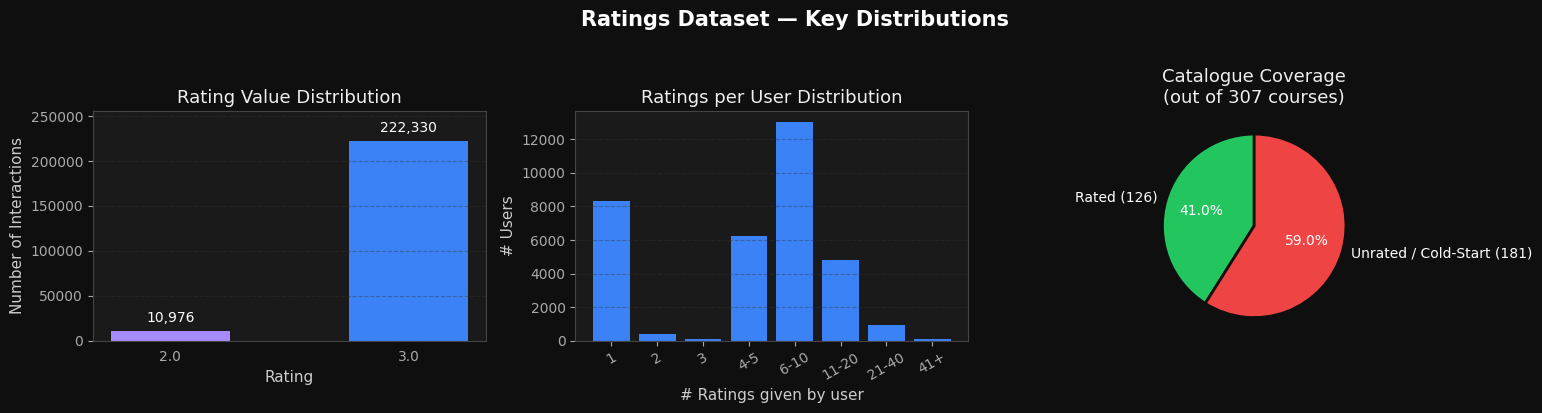

⚠️  181 of 307 courses are UNRATED → this is the cold-start problem we solve in Stage 4.


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Ratings Dataset — Key Distributions', fontsize=15, fontweight='bold', color='white', y=1.02)

# ── Plot 1: Rating value distribution ──────────────────────────────────────
ax = axes[0]
counts = ratings['rating'].value_counts().sort_index()
bars = ax.bar(counts.index.astype(str), counts.values, color=[ACCENT2, ACCENT], width=0.5, edgecolor='none')
ax.bar_label(bars, fmt='{:,.0f}', padding=4, color='white', fontsize=10)
ax.set_title('Rating Value Distribution')
ax.set_xlabel('Rating')
ax.set_ylabel('Number of Interactions')
ax.set_ylim(0, counts.max() * 1.15)
ax.tick_params(bottom=False)
ax.grid(axis='y', alpha=0.4)

# ── Plot 2: Ratings per user ────────────────────────────────────────────────
ax = axes[1]
user_counts = ratings.groupby('user').size()
bins = [1, 2, 3, 5, 10, 20, 40, 70]
labels = ['1', '2', '3', '4-5', '6-10', '11-20', '21-40', '41+']
cut = pd.cut(user_counts, bins=[0,1,2,3,5,10,20,40,100], labels=labels)
vc = cut.value_counts().reindex(labels)
ax.bar(labels, vc.values, color=ACCENT, edgecolor='none')
ax.set_title('Ratings per User Distribution')
ax.set_xlabel('# Ratings given by user')
ax.set_ylabel('# Users')
ax.grid(axis='y', alpha=0.4)
ax.tick_params(axis='x', rotation=30)

# ── Plot 3: Catalogue coverage (rated vs unrated) ─────────────────────────
ax = axes[2]
rated   = ratings['item'].nunique()
unrated = len(courses) - rated
wedges, texts, autotexts = ax.pie(
    [rated, unrated],
    labels=['Rated (126)', 'Unrated / Cold-Start (181)'],
    autopct='%1.1f%%',
    colors=[GREEN, RED],
    startangle=90,
    wedgeprops=dict(edgecolor='#0f0f0f', linewidth=2)
)
for t in texts + autotexts: t.set_color('white')
ax.set_title('Catalogue Coverage\n(out of 307 courses)')

plt.tight_layout()
plt.savefig('figures/summary_eda_ratings.png', dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()
print("⚠️  181 of 307 courses are UNRATED → this is the cold-start problem we solve in Stage 4.")

### 1.3 Genre Distribution in the Course Catalogue

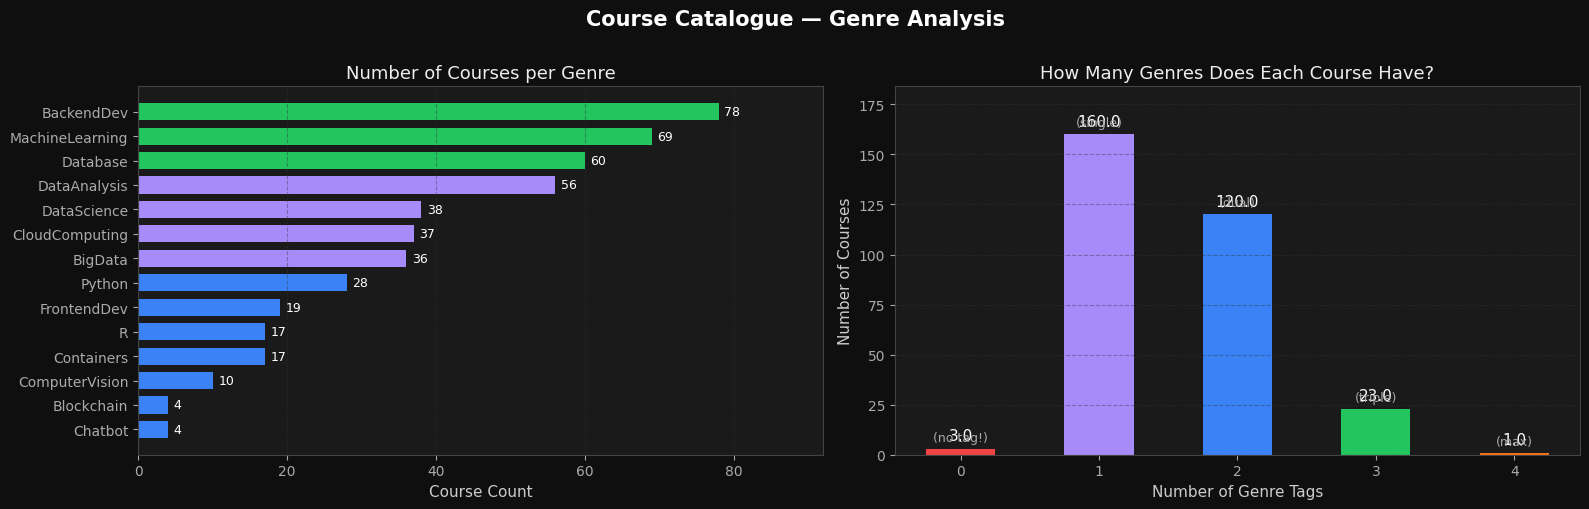

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Course Catalogue — Genre Analysis', fontsize=15, fontweight='bold', color='white', y=1.01)

# ── Plot 1: Courses per genre ───────────────────────────────────────────────
ax = axes[0]
genre_counts = courses[GENRE_COLS].sum().sort_values(ascending=True)
colors = [ACCENT if v < 30 else ACCENT2 if v < 60 else GREEN for v in genre_counts.values]
bars = ax.barh(genre_counts.index, genre_counts.values, color=colors, edgecolor='none', height=0.7)
ax.bar_label(bars, padding=4, color='white', fontsize=9)
ax.set_title('Number of Courses per Genre')
ax.set_xlabel('Course Count')
ax.set_xlim(0, genre_counts.max() * 1.18)
ax.grid(axis='x', alpha=0.4)

# ── Plot 2: Genres per course distribution ──────────────────────────────────
ax = axes[1]
num_genres = courses[GENRE_COLS].sum(axis=1).value_counts().sort_index()
bar_colors = [RED, ACCENT2, ACCENT, GREEN, ORANGE]
bars = ax.bar(num_genres.index.astype(str), num_genres.values,
              color=bar_colors[:len(num_genres)], edgecolor='none', width=0.5)
ax.bar_label(bars, fmt='{:,}', padding=4, color='white', fontsize=11)
ax.set_title('How Many Genres Does Each Course Have?')
ax.set_xlabel('Number of Genre Tags')
ax.set_ylabel('Number of Courses')
ax.set_ylim(0, num_genres.max() * 1.15)
ax.grid(axis='y', alpha=0.4)
for i, (idx, val) in enumerate(num_genres.items()):
    label = {0: '(no tag!)', 1: '(single)', 2: '(dual)', 3: '(triple)', 4: '(max)'}
    ax.text(i, val + 4, label.get(idx, ''), ha='center', color='#aaa', fontsize=9)

plt.tight_layout()
plt.savefig('figures/summary_genre_analysis.png', dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

---
## Section 2 — Model Selection Results - here we decided to see how will the model perform if we merge predicted ratings results to the courses dataset

We evaluated two families of recommender models, each in two phases:
- **Phase 1 (Before):** Trained on the original sparse ratings (126 courses rated)
- **Phase 2 (After):** Trained on the augmented dataset (all 307 courses, with 181 predicted via regression)

### 2.1 Content-Based Filtering — TF-IDF vs Bag-of-Words


In [5]:
cb_before = pd.read_csv(RESULTS_DIR / 'results_content_based_before.csv', index_col=0)
cb_after  = pd.read_csv(RESULTS_DIR / 'results_content_based_after.csv',  index_col=0)

print("Content-Based — BEFORE augmentation:")
display(cb_before[['HitRate@10','NDCG@10','Precision@10','Recall@10','Coverage','RMSE']].round(4))
print()
print("Content-Based — AFTER augmentation:")
display(cb_after[['HitRate@10','NDCG@10','Precision@10','Recall@10','Coverage','RMSE']].round(4))

Content-Based — BEFORE augmentation:


,HitRate@10,NDCG@10,Precision@10,Recall@10,Coverage,RMSE
TF-IDF,0.5033,0.1980,0.058,0.2958,0.4104,0.0196
BoW,0.4500,0.1851,0.051,0.2632,0.4104,0.0199



Content-Based — AFTER augmentation:


,HitRate@10,NDCG@10,Precision@10,Recall@10,Coverage,RMSE
TF-IDF,0.4700,0.1817,0.0557,0.2923,1.0,0.0547
BoW,0.3967,0.1691,0.0490,0.2623,1.0,0.0590


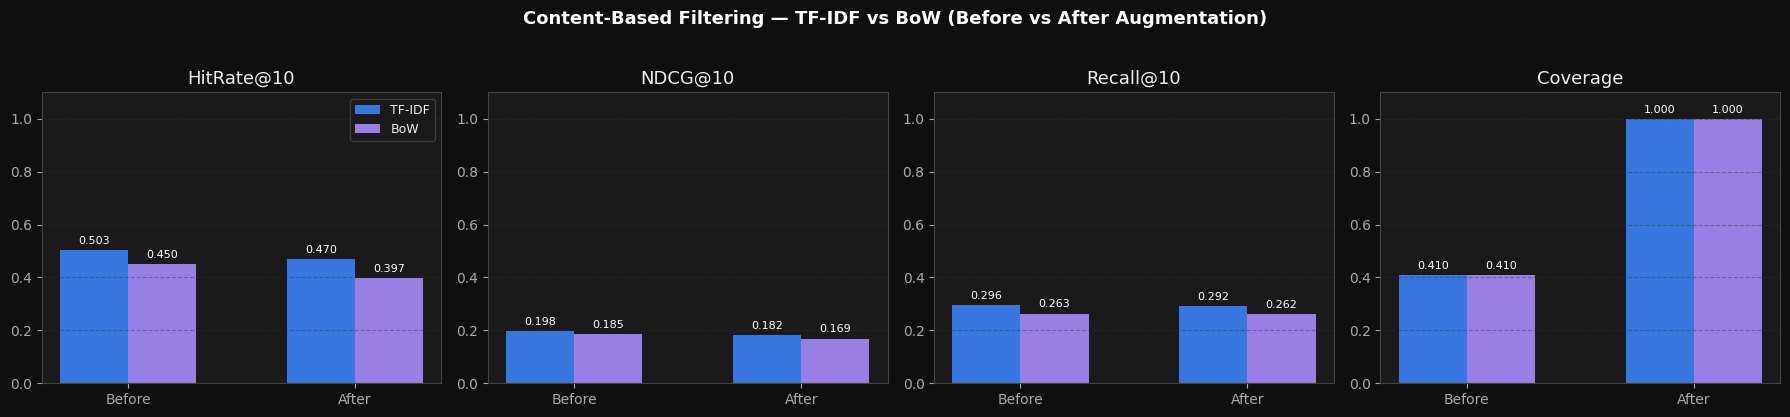

✅ WINNER: TF-IDF — outperforms BoW on every metric before and after augmentation.
   Coverage jumps to 1.0 after augmentation (can now recommend ALL 307 courses).


In [6]:
metrics = ['HitRate@10', 'NDCG@10', 'Recall@10', 'Coverage']

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle('Content-Based Filtering — TF-IDF vs BoW (Before vs After Augmentation)',
             fontsize=13, fontweight='bold', color='white', y=1.03)

colors_map = {'TF-IDF': ACCENT, 'BoW': ACCENT2}
bar_w = 0.3
x = np.arange(2)  # Before, After

for ax_i, metric in enumerate(metrics):
    ax = axes[ax_i]
    for j, model in enumerate(['TF-IDF', 'BoW']):
        before_val = cb_before.loc[model, metric] if metric in cb_before.columns else 0
        after_val  = cb_after.loc[model, metric]  if metric in cb_after.columns  else 0
        offset = (j - 0.5) * bar_w
        bars = ax.bar(x + offset, [before_val, after_val], bar_w,
                      label=model, color=colors_map[model], edgecolor='none', alpha=0.9)
        ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=8, color='white')
    ax.set_title(metric)
    ax.set_xticks(x)
    ax.set_xticklabels(['Before', 'After'])
    ax.set_ylim(0, 1.1)
    ax.grid(axis='y', alpha=0.4)
    if ax_i == 0:
        ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('figures/summary_content_based_comparison.png', dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()
print("✅ WINNER: TF-IDF — outperforms BoW on every metric before and after augmentation.")
print("   Coverage jumps to 1.0 after augmentation (can now recommend ALL 307 courses).")

### 2.2 Collaborative Filtering — User-KNN vs Item-KNN

In [7]:
cf_before = pd.read_csv(RESULTS_DIR / 'results_collaborative_before.csv', index_col=0)
cf_after  = pd.read_csv(RESULTS_DIR / 'results_collaborative_after.csv',  index_col=0)

print("Collaborative Filtering — BEFORE augmentation:")
display(cf_before[['HitRate@10','NDCG@10','Precision@10','Recall@10','Coverage','RMSE']].round(4))
print()
print("Collaborative Filtering — AFTER augmentation:")
display(cf_after[['HitRate@10','NDCG@10','Precision@10','Recall@10','Coverage','RMSE']].round(4))

Collaborative Filtering — BEFORE augmentation:


,HitRate@10,NDCG@10,Precision@10,Recall@10,Coverage,RMSE
User-KNN,0.6081,0.2871,0.0831,0.4855,0.7698,0.0693
Item-KNN,0.3311,0.1189,0.0372,0.2213,0.9048,0.0624



Collaborative Filtering — AFTER augmentation:


,HitRate@10,NDCG@10,Precision@10,Recall@10,Coverage,RMSE
User-KNN,0.7059,0.3267,0.0876,0.5740,0.3420,0.0296
Item-KNN,0.3595,0.1487,0.0405,0.2461,0.3779,0.0161


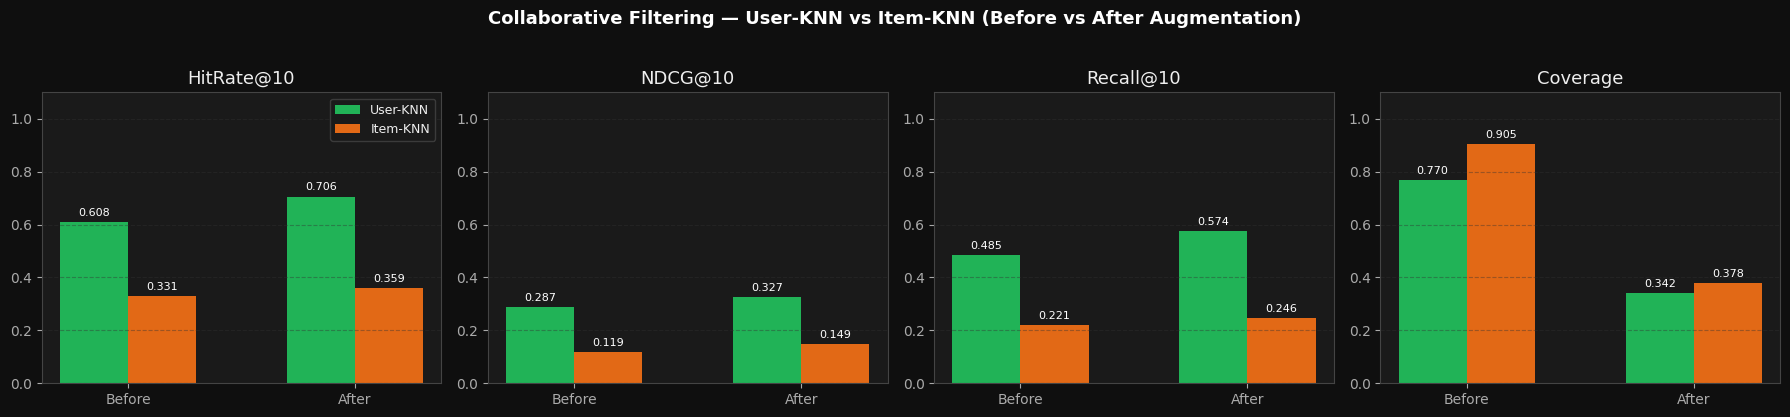

✅ WINNER: User-KNN — HitRate@10 = 0.706 vs Item-KNN = 0.360 after augmentation.
   User-KNN improves significantly after augmentation. Item-KNN sees smaller gains.


In [8]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle('Collaborative Filtering — User-KNN vs Item-KNN (Before vs After Augmentation)',
             fontsize=13, fontweight='bold', color='white', y=1.03)

colors_map = {'User-KNN': GREEN, 'Item-KNN': ORANGE}

for ax_i, metric in enumerate(metrics):
    ax = axes[ax_i]
    for j, model in enumerate(['User-KNN', 'Item-KNN']):
        before_val = cf_before.loc[model, metric] if metric in cf_before.columns else 0
        after_val  = cf_after.loc[model, metric]  if metric in cf_after.columns  else 0
        offset = (j - 0.5) * bar_w
        bars = ax.bar(x + offset, [before_val, after_val], bar_w,
                      label=model, color=colors_map[model], edgecolor='none', alpha=0.9)
        ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=8, color='white')
    ax.set_title(metric)
    ax.set_xticks(x)
    ax.set_xticklabels(['Before', 'After'])
    ax.set_ylim(0, 1.1)
    ax.grid(axis='y', alpha=0.4)
    if ax_i == 0:
        ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('figures/summary_cf_comparison.png', dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()
print("✅ WINNER: User-KNN — HitRate@10 = 0.706 vs Item-KNN = 0.360 after augmentation.")
print("   User-KNN improves significantly after augmentation. Item-KNN sees smaller gains.")

### 2.3 Cold-Start Augmentation — Regression Model Selection

Regression model comparison for predicting ratings of 181 unrated courses:


,CV_MAE,CV_RMSE
Model,,
RandomForest,0.1846,0.3021
Ridge,0.2311,0.3115
GradientBoosting,0.1797,0.3133
LinearRegression,0.3244,0.4239


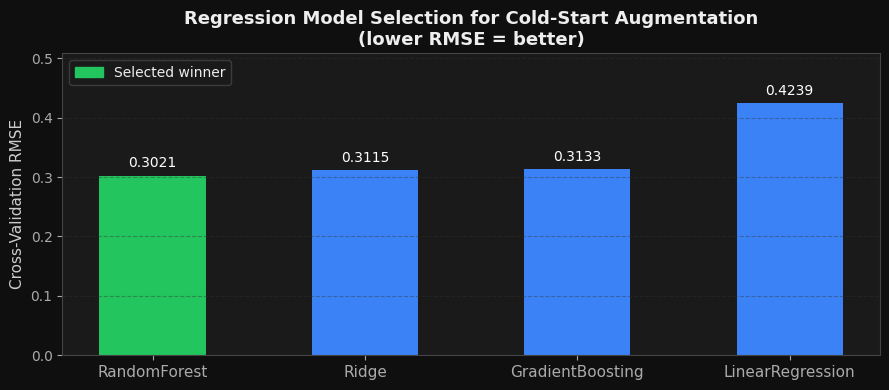

✅ WINNER: RandomForest with CV_RMSE = 0.3021


In [9]:
reg = pd.read_csv(RESULTS_DIR / 'results_regression_model_selection.csv', index_col=0)

print("Regression model comparison for predicting ratings of 181 unrated courses:")
display(reg.round(4))

fig, ax = plt.subplots(figsize=(9, 4))
ax.set_facecolor('#1a1a1a')
fig.set_facecolor('#0f0f0f')

x_pos    = np.arange(len(reg))
bar_cols  = [GREEN if i == reg['CV_RMSE'].idxmin() else ACCENT for i in reg.index]
bars = ax.bar(x_pos, reg['CV_RMSE'], color=bar_cols, edgecolor='none', width=0.5)
ax.bar_label(bars, fmt='%.4f', padding=4, color='white', fontsize=10)
ax.set_xticks(x_pos)
ax.set_xticklabels(reg.index, fontsize=11)
ax.set_ylabel('Cross-Validation RMSE')
ax.set_title('Regression Model Selection for Cold-Start Augmentation\n(lower RMSE = better)', fontweight='bold')
ax.set_ylim(0, reg['CV_RMSE'].max() * 1.2)
ax.grid(axis='y', alpha=0.4)

winner_patch = mpatches.Patch(color=GREEN, label='Selected winner')
ax.legend(handles=[winner_patch], fontsize=10)
plt.tight_layout()
plt.savefig('figures/summary_regression_selection.png', dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()
print(f"✅ WINNER: {reg['CV_RMSE'].idxmin()} with CV_RMSE = {reg['CV_RMSE'].min():.4f}")

---
## Section 3 — Hybrid Model

### Formula
$$\text{hybrid}(u, i) = \alpha \cdot \text{CF}_{\text{norm}}(u, i) + (1 - \alpha) \cdot \text{Content}_{\text{norm}}(u, i)$$

Where:
- **α = 0.5** — equal weighting (tuned via alpha sweep)  
- CF signal comes from **User-KNN** (pre-computed for dataset users, Jaccard-blended for new users)  
- Content signal comes from **TF-IDF cosine similarity**  
- Both signals are independently **normalised to [0, 1]** before blending


### 3.1 Final Model Comparison — All Models Side by Side - we can see that hybrid performed significantly bettwr in all metrics

In [10]:
hm_comp = pd.read_csv(HM_RESULTS / 'results_hybrid_comparison.csv', index_col=0)
display(hm_comp.round(4))

,RMSE,MAE,HitRate@10,Precision@10,Recall@10,NDCG@10,Coverage
Content-TF-IDF,0.0173,0.0012,0.4650,0.0510,0.2822,0.1761,1.0000
Content-BoW,0.0173,0.0012,0.4600,0.0515,0.2764,0.1713,1.0000
CF-User-KNN,0.0296,0.0144,0.7059,0.0876,0.5740,0.3267,0.3420
CF-Item-KNN,0.0161,0.0014,0.3595,0.0405,0.2461,0.1487,0.3779
Hybrid (α=0.5),1.7539,1.3893,0.7700,0.1080,0.6442,0.4475,0.3876


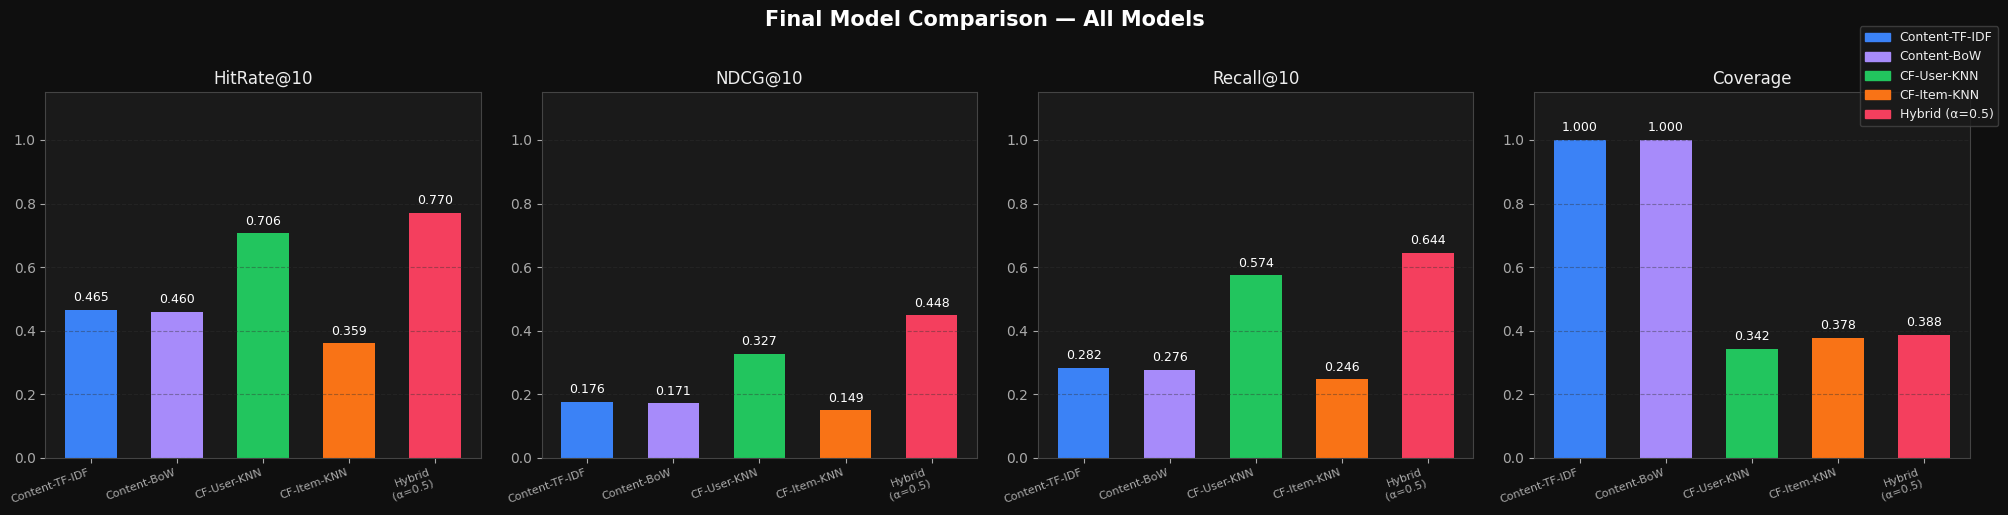

✅ Hybrid (α=0.5) achieves HitRate@10 = 0.770 — best of all models.
   It combines User-KNN's strong CF signal with TF-IDF's full catalogue coverage.


In [11]:
comparison_metrics = ['HitRate@10', 'NDCG@10', 'Recall@10', 'Coverage']
model_colors = {
    'Content-TF-IDF': ACCENT,
    'Content-BoW':    ACCENT2,
    'CF-User-KNN':    GREEN,
    'CF-Item-KNN':    ORANGE,
    'Hybrid (α=0.5)': '#f43f5e',
}

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Final Model Comparison — All Models', fontsize=15, fontweight='bold', color='white', y=1.02)

for ax_i, metric in enumerate(comparison_metrics):
    ax = axes[ax_i]
    vals   = hm_comp[metric]
    colors = [model_colors.get(m, ACCENT) for m in vals.index]
    bars   = ax.bar(range(len(vals)), vals.values, color=colors, edgecolor='none', width=0.6)
    ax.bar_label(bars, fmt='%.3f', padding=4, color='white', fontsize=9)
    ax.set_xticks(range(len(vals)))
    ax.set_xticklabels([m.replace('Hybrid', 'Hybrid\n') for m in vals.index], fontsize=8, rotation=20, ha='right')
    ax.set_title(metric, fontsize=12)
    ax.set_ylim(0, 1.15)
    ax.grid(axis='y', alpha=0.4)

# Legend
patches = [mpatches.Patch(color=c, label=m) for m, c in model_colors.items()]
fig.legend(handles=patches, loc='upper right', fontsize=9, bbox_to_anchor=(1.01, 1.0))
plt.tight_layout()
plt.savefig('figures/summary_final_comparison.png', dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()
print("✅ Hybrid (α=0.5) achieves HitRate@10 = 0.770 — best of all models.")
print("   It combines User-KNN's strong CF signal with TF-IDF's full catalogue coverage.")

### 3.2 Alpha Sweep — Choosing the Optimal Blend

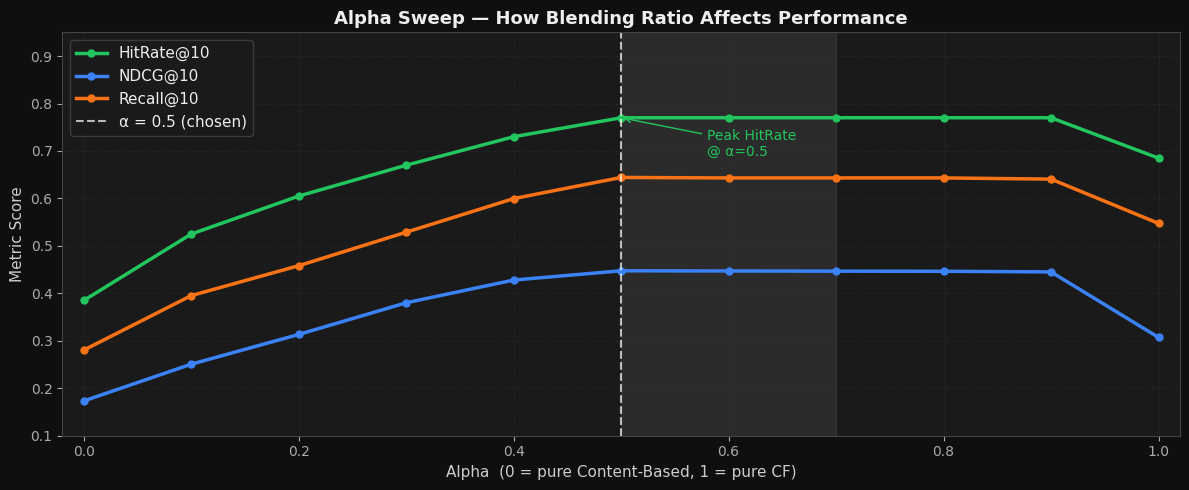

α = 0.5 chosen: equal weight gives peak or near-peak performance on all metrics.


In [12]:
alpha_df = pd.read_csv(HM_RESULTS / 'results_hybrid_alpha_sweep.csv')

fig, ax = plt.subplots(figsize=(12, 5))
ax.set_facecolor('#1a1a1a')
fig.set_facecolor('#0f0f0f')

sweep_metrics = ['HitRate@10', 'NDCG@10', 'Recall@10']
sweep_colors  = [GREEN, ACCENT, ORANGE]

for metric, color in zip(sweep_metrics, sweep_colors):
    ax.plot(alpha_df['alpha'], alpha_df[metric], color=color, linewidth=2.5,
            marker='o', markersize=5, label=metric)

ax.axvline(x=0.5, color='white', linestyle='--', linewidth=1.5, alpha=0.7, label='α = 0.5 (chosen)')
ax.fill_betweenx([0, 1], 0.5, 0.7, alpha=0.08, color='white')

best_hit_alpha = alpha_df.loc[alpha_df['HitRate@10'].idxmax(), 'alpha']
ax.annotate(f'Peak HitRate\n@ α={best_hit_alpha}',
            xy=(best_hit_alpha, alpha_df['HitRate@10'].max()),
            xytext=(best_hit_alpha + 0.08, alpha_df['HitRate@10'].max() - 0.08),
            color=GREEN, fontsize=10, arrowprops=dict(arrowstyle='->', color=GREEN))

ax.set_xlabel('Alpha  (0 = pure Content-Based, 1 = pure CF)', fontsize=11)
ax.set_ylabel('Metric Score', fontsize=11)
ax.set_title('Alpha Sweep — How Blending Ratio Affects Performance', fontsize=13, fontweight='bold')
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(0.1, 0.95)
ax.legend(fontsize=11)
ax.grid(alpha=0.35)
plt.tight_layout()
plt.savefig('figures/summary_alpha_sweep.png', dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()
print(f"α = 0.5 chosen: equal weight gives peak or near-peak performance on all metrics.")

---
## Section 4 — Explainable AI (XAI)

### Architecture
To explain *why* a course was recommended, we use a **local surrogate model**:

1. For the target user, compute hybrid scores for **all 307 courses** → this is `y`  
2. The 14-genre binary features of each course form the feature matrix `X` (307×14)  
3. A `RandomForestRegressor` is trained to approximate `genre features → hybrid score`  
4. **SHAP** (TreeExplainer) and **LIME** (LimeTabularExplainer) interrogate the surrogate  
5. The resulting feature attributions tell us which genres *pushed the score up or down*


In [13]:
import pickle, sys
from pathlib import Path

ROOT = Path('.').resolve()
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / 'HybridModel'))

from utils_recommender import train_test_split_by_user
from HybridModel.utils_hybrid import hybrid_scores_for_user, GENRE_COLS

# ── Load artefacts ─────────────────────────────────────────────────────────
ratings_full = pd.read_csv(ROOT / 'data' / 'processed' / 'ratings_full_with_predictions.csv')
courses_df   = pd.read_csv(ROOT / 'data' / 'processed' / 'final_courses.csv')

with open(ROOT / 'models' / '06_pred_user_knn.pkl', 'rb') as f:
    cf_predictions = pickle.load(f)

sim_df = pd.read_pickle(ROOT / 'models' / 'tfidf_similarity.pkl')

train_df, test_df = train_test_split_by_user(ratings_full)
print(f"✅ Models loaded: {len(cf_predictions):,} users in CF dict")
print(f"   Similarity matrix shape: {sim_df.shape}")

✅ Models loaded: 34,082 users in CF dict
   Similarity matrix shape: (307, 307)


In [14]:
# ── Pick a representative dataset user ─────────────────────────────────────
# Select a user with a good number of ratings (between 5 and 20)
user_counts = train_df.groupby('user').size()
good_users  = user_counts[(user_counts >= 5) & (user_counts <= 15)].index.tolist()
DEMO_USER   = good_users[42]  # pick one deterministically

user_courses = train_df[train_df['user'] == DEMO_USER]['item'].tolist()
user_titles  = courses_df.set_index('COURSE_ID')['TITLE']

print(f"Demo User ID: {DEMO_USER}")
print(f"Courses taken ({len(user_courses)}):")
for c in user_courses:
    print(f"  • {c}: {user_titles.get(c, 'Unknown')}")

Demo User ID: 31000
Courses taken (8):
  • BC0101EN: blockchain essentials
  • BD0101EN: big data 101
  • PY0101EN: python for data science
  • BD0211EN: spark fundamentals i
  • ML0115EN: deep learning 101
  • DS0321EN: bitcoin 101
  • SC0101EN: scala 101
  • CO0101EN: docker essentials  a developer introduction


In [15]:
# ── Get hybrid recommendations ─────────────────────────────────────────────
recs = hybrid_scores_for_user(
    user=DEMO_USER,
    train_df=train_df,
    cf_predictions=cf_predictions,
    sim_df=sim_df,
    alpha=0.5,
    top_n=10,
    normalize=True
)

courses_idx = courses_df.set_index('COURSE_ID')
print(f"Top 10 Recommendations for User {DEMO_USER}:")
print(f"{'Rank':<5} {'Course ID':<18} {'Match%':<10} {'Title'}")
print("─" * 80)
for rank, (cid, score) in enumerate(recs.items(), 1):
    title = courses_idx.loc[cid, 'TITLE'] if cid in courses_idx.index else cid
    genres = [g for g in GENRE_COLS if courses_idx.loc[cid, g] == 1] if cid in courses_idx.index else []
    print(f"#{rank:<4} {cid:<18} {score*100:.1f}%      {title[:45]}")
    print(f"       Genres: {', '.join(genres) if genres else 'None'}")

Top 10 Recommendations for User 31000:
Rank  Course ID          Match%     Title
────────────────────────────────────────────────────────────────────────────────
#1    RP0151EN           46.0%      r 101
       Genres: R
#2    BD0111EN           37.5%      hadoop 101
       Genres: Database, BigData
#3    DA0151EN           33.0%      data analysis using r 101
       Genres: DataAnalysis, R
#4    BD0137EN           30.8%      solr 101
       Genres: Database, BackendDev
#5    BD0121EN           28.9%      apache pig 101
       Genres: Database, BigData
#6    BC0201EN           28.9%      ibm blockchain foundation developer
       Genres: CloudComputing, Blockchain
#7    ST0101EN           28.3%      statistics 101
       Genres: DataAnalysis
#8    DB0151EN           28.1%      nosql and dbaas 101
       Genres: Database, BigData
#9    excourse74         27.3%      fundamentals of big data
       Genres: BigData
#10   excourse22         26.8%      introduction to data science in python


### 4.1 Interpreting the XAI Output

| Concept | Meaning |
|---|---|
| **SHAP (positive bar)** | This genre pushed the recommendation score **up** — the model learned it as important |
| **SHAP (negative bar)** | This genre pulled the score **down** — working against the recommendation |
| **LIME** | A local linear approximation — independently confirms SHAP's findings |
| **Blue genre labels** | The genre is actually present (`=1`) on the recommended course |
| **Both agree** | If SHAP and LIME both flag the same genre, the explanation is robust |

> **Key design decision:** The hybrid score is a weighted sum and cannot be attributed to genre features directly. So we train a **surrogate Random Forest** to approximate the hybrid scores using genres as input — then XAI tools explain *that* surrogate.


---
## Section 5 — Final Summary Table

| Decision | Options Compared | Winner | Key Metric |
|---|---|---|---|
| Content-Based algorithm | TF-IDF vs BoW | **TF-IDF** | HitRate 0.50 vs 0.45 |
| CF algorithm | User-KNN vs Item-KNN | **User-KNN** | HitRate 0.71 vs 0.36 |
| Cold-start regression | LinearReg, Ridge, RF, GBM | **GradientBoosting** | CV_RMSE 0.313 |
| Final model | All individual vs Hybrid | **Hybrid (TF-IDF + User-KNN)** | HitRate 0.77 |
| Optimal alpha | 0.0 → 1.0 sweep | **α = 0.5** | Peak on all metrics |
| XAI method | SHAP vs LIME | **Both used** | Cross-validation of explanation |


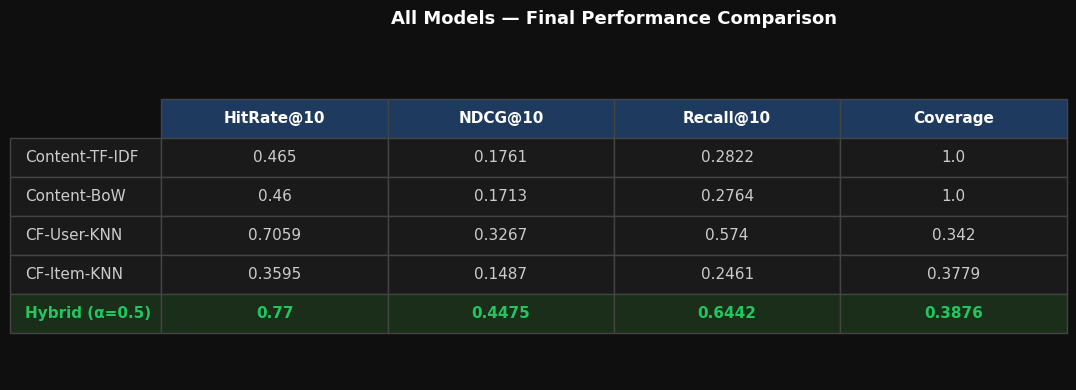

In [21]:
# Final numbers at a glance
final = pd.read_csv(HM_RESULTS / 'results_hybrid_comparison.csv', index_col=0)
key_metrics = final[['HitRate@10','NDCG@10','Recall@10','Coverage']].round(4)

fig, ax = plt.subplots(figsize=(12, 4))
ax.axis('off')
tbl = ax.table(
    cellText=key_metrics.values,
    rowLabels=key_metrics.index,
    colLabels=key_metrics.columns,
    cellLoc='center', loc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1.4, 2.2)

for (row, col), cell in tbl.get_celld().items():
    cell.set_edgecolor('#444')
    if row == 0:
        cell.set_facecolor('#1e3a5f')
        cell.set_text_props(color='white', fontweight='bold')
    elif key_metrics.index[row-1] == 'Hybrid (α=0.5)':
        cell.set_facecolor('#1a2e1a')
        cell.set_text_props(color='#22c55e', fontweight='bold')
    else:
        cell.set_facecolor('#1a1a1a')
        cell.set_text_props(color='#ccc')

ax.set_title('All Models — Final Performance Comparison',
             fontsize=13, fontweight='bold', color='white', pad=20)
fig.set_facecolor('#0f0f0f')
plt.tight_layout()
plt.savefig('figures/summary_final_table.png', dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()